In [57]:
import numpy as np, math
from scipy.optimize import brentq
try:
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    SPARSE_OK = True
except Exception:
    SPARSE_OK = False

# NOTE:
# self.t_v is the negative of the t_v used in the LaTeX notes:
#     t_v_code = - t_v_LaTeX.
# Therefore B_± = t_c exp(∓iK) + t_v_code,
# and the one-magnon hole-hopping matrix entries are +t_v_code.

class ExcitonMagnonSolver:
    """
    Three-sector exciton–magnon Green function on a 1-D FM chain.

    Basis (ΔS^z_tot = 0):
        |K;R⟩         singlet        (zero magnon)
        |K,T⁰;R⟩     S_z=0 triplet  (zero magnon)
        |K,T⁺;R,m⟩   T⁺ exciton + compensating magnon at relative site m

    R-block:  g_R = [ G_S(R), G_T0(R), G_T+(R,-M), …, G_T+(R,M) ]
    Full:     G   = [ g_{-Rmax}, …, g_{Rmax} ]
    """

    def __init__(self, t_c, t_v, Delta, J_FM, Je, Jv, s, gamma, U, Rmax, M):
        # ── model parameters ──
        self.t_c   = float(t_c)
        self.t_v   = float(t_v)
        self.Delta = float(Delta)
        self.J_FM  = float(J_FM)
        self.Je    = float(Je)
        self.Jv    = float(Jv)
        self.s     = float(s)
        self.gamma = float(gamma)
        self.U     = float(U)

        # ── truncation ──
        self.Rmax = int(Rmax)
        self.M    = int(M)
        #assert self.M >= self.Rmax, "Need M ≥ Rmax so m = R is always retained"

        # -- build index dictionary --
        self._build_basis()

        self.Ntot = len(self.idx2pair)
        self.alpha   = self.gamma * math.sqrt(self.s) / 2.0   # γ√s / 2
        self.Delta_J = (self.Jv - self.Je) * self.s / 2.0     # (Jv−Je)s / 2

    def _build_basis(self):
        self.idx2pair = []
        self.pair2idx = {}
        def push(key):
            self.pair2idx[key] = len(self.idx2pair)
            self.idx2pair.append(key)

        for R in range(-self.Rmax, self.Rmax + 1):
            push(('S', R))
            push(('T0', R))
            lo = min(-self.M, R - self.M)
            hi = max( self.M, R + self.M)
            for m in range(lo, hi + 1):
                if min(abs(m), abs(m - R)) <= self.M:
                    push(('Tp', R, m))



    # ════════════════════════════════════════════════════
    #  Reference dispersions
    # ════════════════════════════════════════════════════
    def eps_c(self, k): return 2.0*self.t_c*np.cos(k) + self.Delta
    def eps_v(self, k): return 2.0*self.t_v*np.cos(k)
    def eps_h(self, k): return -self.eps_v(k)

    # ════════════════════════════════════════════════════
    #  Index helpers
    # ════════════════════════════════════════════════════
    def _r(self, R):        return R + self.Rmax
    def idx_S(self, R):     return self.pair2idx[('S', R)]
    def idx_T0(self, R):    return self.pair2idx[('T0', R)]
    def idx_Tp(self, R, m): return self.pair2idx[('Tp', R, m)]
    def _R_ok(self, R):     return -self.Rmax <= R <= self.Rmax
    def _m_ok(self, R, m):  return min(abs(m), abs(m-R)) <= self.M

    # =====================================================
    # Adder
    # =================================================
    def add_if(self, add, i, key, val):
        j = self.pair2idx.get(key)
        if j is not None and val != 0:
            add(i, j, val)

    # ════════════════════════════════════════════════════
    #  Diagonal energies
    # ════════════════════════════════════════════════════
    def _E_Tp(self, R, m):
        """E^{T+}_{R,m} = (Je+Jv)s/2 − (Je/2)δ_{m0} − (Jv/2)δ_{mR}"""
        val = (self.Je + self.Jv) * self.s / 2.0
        if m == 0: val -= self.Je / 2.0
        if m == R: val -= self.Jv / 2.0
        return val

    def _diag_S(self, z, R):
        return z - self.Delta + (self.U if R == 0 else 0.0)

    def _diag_T0(self, z, R):
        return z - self.Delta + (self.U if R == 0 else 0.0)

    def _diag_Tp(self, z, R, m):
        return (z - self.Delta - 2.0*self.J_FM*self.s
                + self._E_Tp(R, m)
                + (self.U if R == 0 else 0.0))

    # ════════════════════════════════════════════════════
    #  Row-fill helpers
    # ════════════════════════════════════════════════════
    def _fill_S_row(self, add, R, z, Bp, Bm):
        """Singlet row at given R."""
        i = self.idx_S(R)
        add(i, i, self._diag_S(z, R))
        # hopping in R
        self.add_if(add, i, ('S', R-1), Bp)
        self.add_if(add, i, ('S', R+1), Bm)
        # S ↔ T⁰  (longitudinal s-d)
        add(i, self.idx_T0(R), self.Delta_J)
        # S → T⁺  (transverse s-d)
        add(i, self.idx_Tp(R,0), self.alpha * self.Je)
        self.add_if(add, i, ('Tp', R, R), -self.alpha * self.Jv)

    def _fill_T0_row(self, add, R, z, Bp, Bm):
        """T⁰ row at given R."""
        i = self.idx_T0(R)
        add(i, i, self._diag_T0(z, R))
        self.add_if(add, i, ('T0', R-1), Bp)
        self.add_if(add, i, ('T0', R+1), Bm)
        # T⁰ ↔ S  (longitudinal s-d)
        add(i, self.idx_S(R), self.Delta_J)
        # T⁰ → T⁺  (transverse s-d, note −αJv vs +αJv in singlet)
        add(i, self.idx_Tp(R, 0), self.alpha * self.Je)
        self.add_if(add, i, ('Tp', R, R), self.alpha * self.Jv)

    def _fill_Tp_row(self, add, R, m, z, exp_miK, exp_iK):
        """T⁺ row at given (R, m)."""
        i = self.idx_Tp(R, m)
        add(i, i, self._diag_Tp(z, R, m))

        # magnon hopping in m
        self.add_if(add, i, ('Tp', R, m-1), self.J_FM*self.s)
        self.add_if(add, i, ('Tp', R, m+1), self.J_FM*self.s)

        # electron hopping: (R,m) → (R±1, m±1)
        self.add_if(add, i, ('Tp', R-1, m-1), self.t_c * exp_miK)
        self.add_if(add, i, ('Tp', R+1, m+1), self.t_c * exp_iK)


        # hole hopping: (R,m) → (R±1, m)
        self.add_if(add, i, ('Tp', R-1, m), self.t_v)
        self.add_if(add, i, ('Tp', R+1, m), self.t_v)

        # T⁺ → S, T⁰  (magnon reabsorption)
        if m == 0:
            self.add_if(add, i, ('S', R),  self.alpha*self.Je)
            self.add_if(add, i, ('T0', R), self.alpha*self.Je)
        if m == R:
            self.add_if(add, i, ('S', R),  -self.alpha*self.Jv)
            self.add_if(add, i, ('T0', R),  self.alpha*self.Jv)

    # ════════════════════════════════════════════════════
    #  Assemble  M(z,K) G = e
    # ════════════════════════════════════════════════════
    def assemble(self, z, K):
        z = complex(z); K = float(K)

        exp_iK  = np.exp(1j*K)
        exp_miK = np.exp(-1j*K)
        Bp = self.t_c * exp_miK + self.t_v     # B₊ → couples to R−1
        Bm = self.t_c * exp_iK  + self.t_v     # B₋ → couples to R+1

        if SPARSE_OK:
            rows, cols, data = [], [], []
            def add(i, j, val):
                if val != 0:
                    rows.append(i); cols.append(j); data.append(val)
        else:
            Mat = np.zeros((self.Ntot, self.Ntot), dtype=np.complex128)
            def add(i, j, val):
                if val != 0:
                    Mat[i, j] += val

        e = np.zeros(self.Ntot, dtype=np.complex128)

        for tp in self.idx2pair:
            if tp[0] == 'S':
                self._fill_S_row(add, tp[1], z, Bp, Bm)
            elif tp[0] == 'T0':
                self._fill_T0_row(add, tp[1], z, Bp, Bm)
            elif tp[0] == 'Tp':
                self._fill_Tp_row(add, tp[1], tp[2], z, exp_miK, exp_iK)

        e[self.idx_S(0)] = 1.0

        if SPARSE_OK:
            Mat = sp.csr_matrix((data, (rows, cols)),
                                shape=(self.Ntot, self.Ntot),
                                dtype=np.complex128)
        return Mat, e

    # ════════════════════════════════════════════════════
    #  Accessors
    # ════════════════════════════════════════════════════
    def get_G_S(self, Gvec, R):     return Gvec[self.idx_S(R)]
    def get_G_T0(self, Gvec, R):    return Gvec[self.idx_T0(R)]
    def get_G_Tp(self, Gvec, R, m): return Gvec[self.idx_Tp(R, m)]

    # ════════════════════════════════════════════════════
    #  Solve and spectral
    # ════════════════════════════════════════════════════
    def solve(self, z, K, source='S', Rsrc=0, msrc=0):
        Mat, _ = self.assemble(z, K)
        e = np.zeros(self.Ntot, dtype=np.complex128)
        if source == 'S':
            e[self.idx_S(Rsrc)] = 1.0
        elif source == 'T0':
            e[self.idx_T0(Rsrc)] = 1.0
        elif source == 'Tp':
            e[self.idx_Tp(Rsrc, msrc)] = 1.0
        else:
            raise ValueError("source must be 'S', 'T0', or 'Tp'")
        if SPARSE_OK:
            return spla.spsolve(Mat, e)
        return np.linalg.solve(Mat, e)

    def spectral(self, K, omega, eta, R=0, sector='S', m=None,
                 *, source='S', Rsrc=0, msrc=0):
        z = omega + 1j*eta
        Gvec = self.solve(z, K, source=source, Rsrc=Rsrc, msrc=msrc)
        if sector == 'S':
            G = self.get_G_S(Gvec, R)
        elif sector == 'T0':
            G = self.get_G_T0(Gvec, R)
        elif sector == 'Tp':
            G = self.get_G_Tp(Gvec, R, m)
        else:
            raise ValueError("sector must be 'S', 'T0', or 'Tp'")
        return -np.imag(G) / np.pi

In [58]:
import os, time
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed

s = 1.5
Je = 0.1# <-- works for any Je now
Jv = 0.1
t_c = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = 0.2

params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=0,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=35,
    M=8,
)


k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-7, -2, 200)
eta = 0.01

# Important: put these BEFORE importing numpy/scipy in a fresh kernel if possible.
# They prevent 28 processes × many BLAS threads = oversubscription.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


def effective_cpu_count():
    # Linux / cluster-safe: respects cpuset / Slurm affinity if enforced.
    try:
        return len(os.sched_getaffinity(0))
    except AttributeError:
        return int(os.environ.get("SLURM_CPUS_PER_TASK") or os.cpu_count() or 1)


n_workers = min(28, effective_cpu_count())

print("os.cpu_count() =", os.cpu_count())
print("effective_cpu_count() =", effective_cpu_count())
print("SLURM_CPUS_PER_TASK =", os.environ.get("SLURM_CPUS_PER_TASK"))
print("Using workers =", n_workers)


def compute_column(args):
    i, k, omega_values, eta, params = args

    pid = os.getpid()
    solver = ExcitonMagnonSolver(**params)

    col = np.empty(len(omega_values), dtype=float)
    for j, w in enumerate(omega_values):
        col[j] = solver.spectral(
            k, w,
            eta=eta,
            R=0,
            sector="Tp",
            source="Tp",
            m = 0,#None
            Rsrc=0,
            msrc=0, #None
        )

    return i, col, pid


tasks = [(i, k, omega_values, eta, params) for i, k in enumerate(k_values)]

cols = [None] * len(k_values)
pid_counts = Counter()

t0 = time.time()

with ProcessPoolExecutor(max_workers=n_workers) as ex:
    futures = [ex.submit(compute_column, task) for task in tasks]

    for done, fut in enumerate(as_completed(futures), 1):
        i, col, pid = fut.result()
        cols[i] = col
        pid_counts[pid] += 1

        if done % 10 == 0 or done == len(futures):
            print(
                f"Finished {done}/{len(tasks)} k-columns | "
                f"worker PIDs seen: {len(pid_counts)}/{n_workers} | "
                f"elapsed: {time.time() - t0:.1f}s",
                flush=True,
            )

spectral_2d = np.stack(cols, axis=1)

print("Number of distinct worker processes used:", len(pid_counts))

spectral_cpu = spectral_2d.copy()

os.cpu_count() = 28
effective_cpu_count() = 28
SLURM_CPUS_PER_TASK = 28
Using workers = 28
Finished 10/200 k-columns | worker PIDs seen: 10/28 | elapsed: 9.7s
Finished 20/200 k-columns | worker PIDs seen: 20/28 | elapsed: 9.7s
Finished 30/200 k-columns | worker PIDs seen: 28/28 | elapsed: 18.8s
Finished 40/200 k-columns | worker PIDs seen: 28/28 | elapsed: 18.9s
Finished 50/200 k-columns | worker PIDs seen: 28/28 | elapsed: 19.0s
Finished 60/200 k-columns | worker PIDs seen: 28/28 | elapsed: 28.0s
Finished 70/200 k-columns | worker PIDs seen: 28/28 | elapsed: 28.1s
Finished 80/200 k-columns | worker PIDs seen: 28/28 | elapsed: 28.4s
Finished 90/200 k-columns | worker PIDs seen: 28/28 | elapsed: 37.2s
Finished 100/200 k-columns | worker PIDs seen: 28/28 | elapsed: 37.3s
Finished 110/200 k-columns | worker PIDs seen: 28/28 | elapsed: 37.7s
Finished 120/200 k-columns | worker PIDs seen: 28/28 | elapsed: 46.3s
Finished 130/200 k-columns | worker PIDs seen: 28/28 | elapsed: 46.5s
Finished 1

In [59]:
from matplotlib.cm import ScalarMappable
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "text.usetex": False,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}\usepackage{amsmath}",  # lighter than newtx
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "mathtext.fontset": "stix",
    "axes.labelsize": 20, "axes.titlesize": 20,  # Slightly smaller for PRB style
    "xtick.labelsize": 20, "ytick.labelsize": 20,  # Smaller tick labels
    "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,  # Add minor ticks
    "legend.frameon": False,  # No frame for cleaner look
    "legend.fontsize": 20,  # Smaller legend font
    "lines.linewidth": 1.2,  # Slightly thicker lines
})

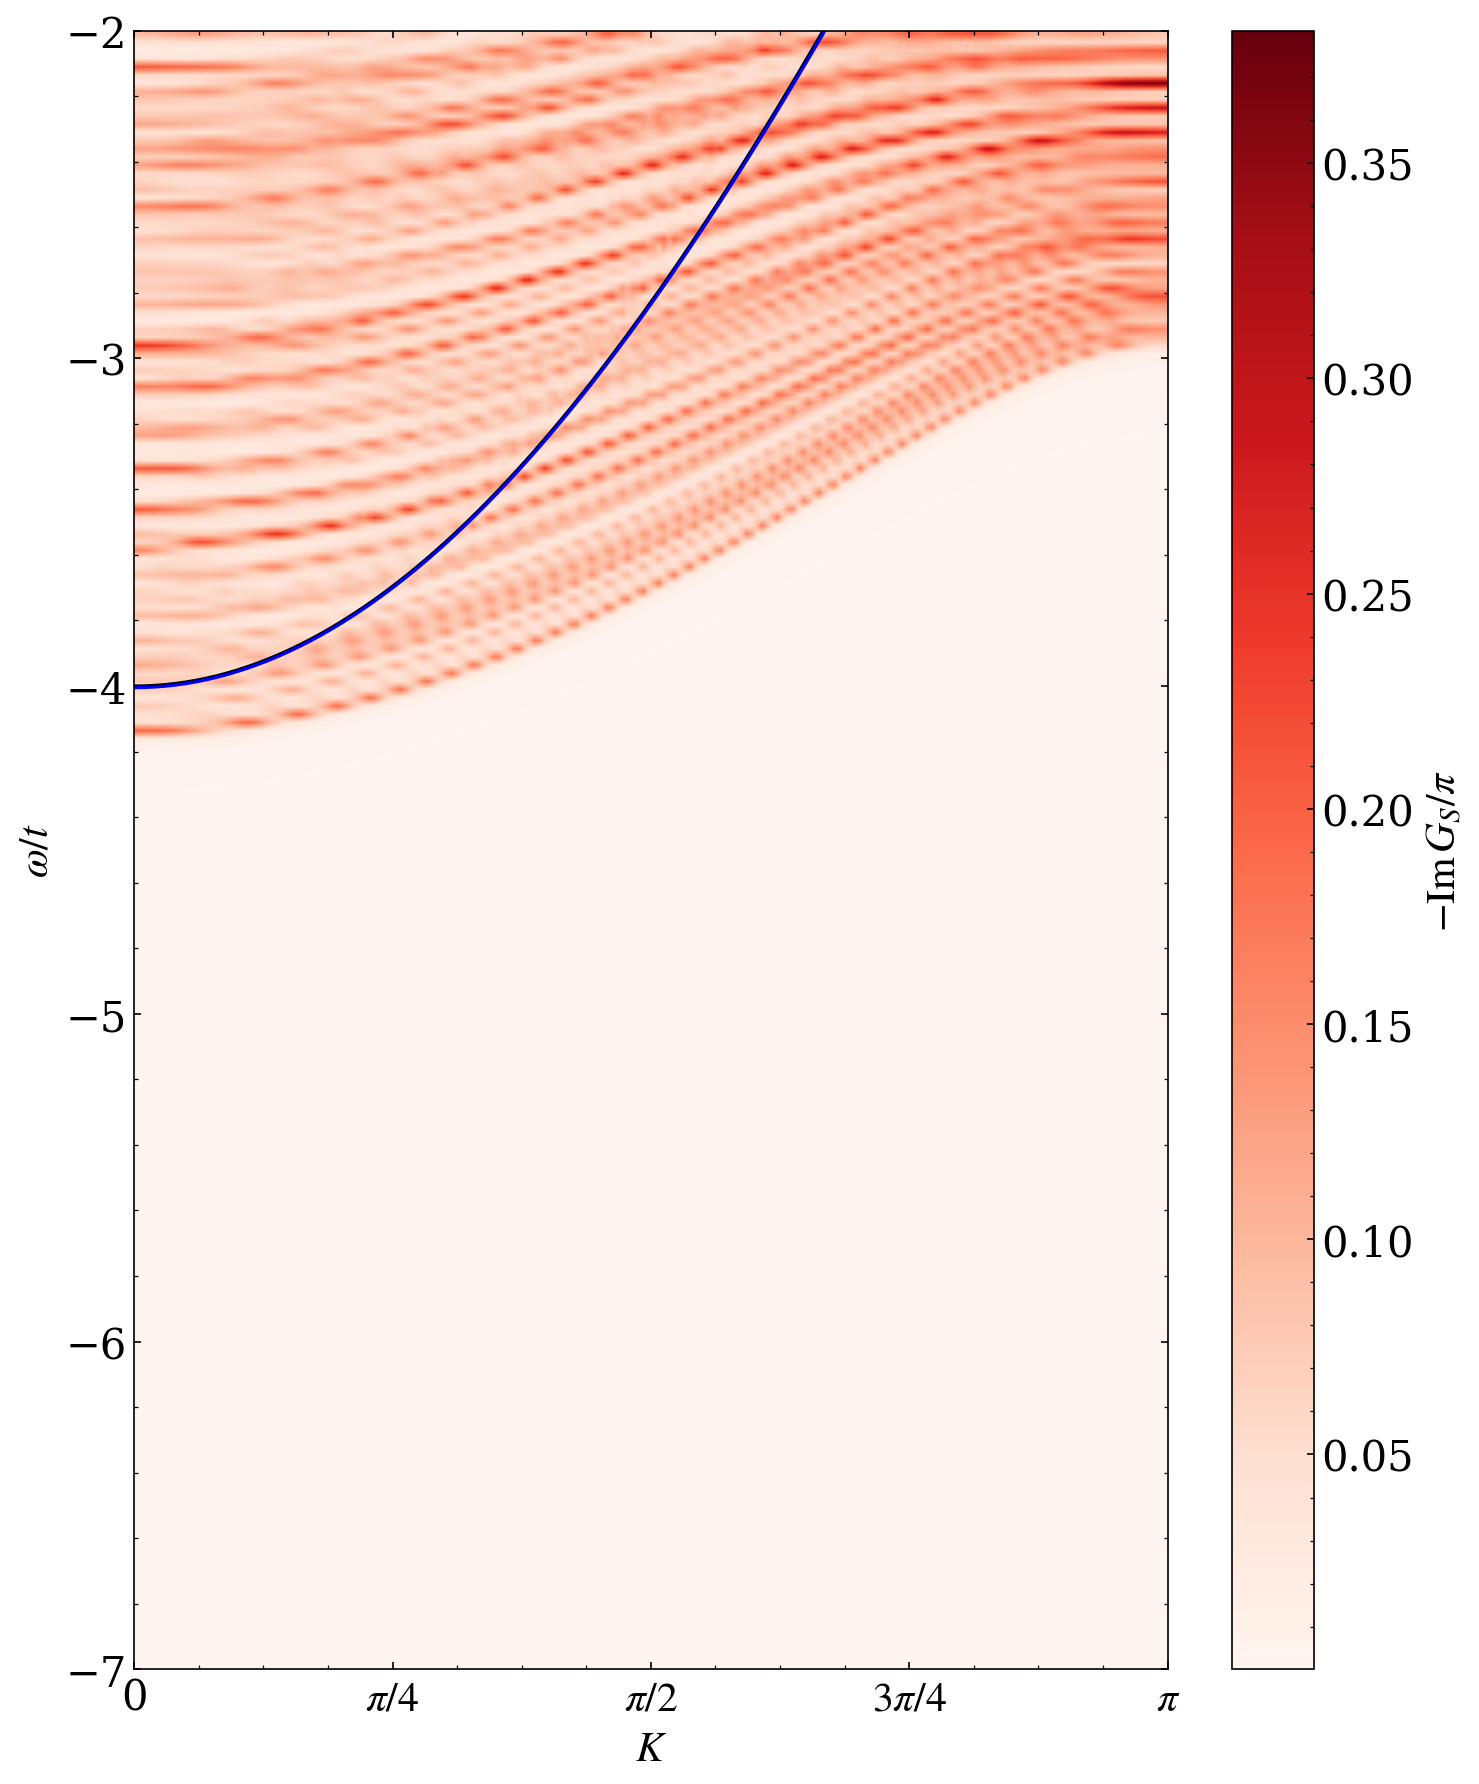

In [60]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(
    spectral_2d,
    origin='lower',
    extent=[k_values[0], k_values[-1], omega_values[0], omega_values[-1]],
    aspect='auto',
    cmap='Reds',
    interpolation='bilinear',
)

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\omega / t$')
plt.plot(k_values, -2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color = "k", lw = 1.5)
plt.plot(k_values, -np.sqrt(U**2 + 4 * (t_v**2 + t_c**2 + 2*t_c*t_v*np.cos(k_values))), color = "b", lw = 1.5)
# Nice k-axis ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi / 4))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: {0: '0', 1: r'$\pi/4$', 2: r'$\pi/2$', 3: r'$3\pi/4$', 4: r'$\pi$'}
    .get(round(x / (np.pi/4)), f'{x:.2f}')
))
ax.set_ylim(-7, -2)
fig.colorbar(im, ax=ax, label=r'$-\mathrm{Im}\,G_S / \pi$')
fig.tight_layout()
plt.show()

In [61]:
from scipy.optimize import brentq


# =====================================================
# Model
# =====================================================
class RealSpaceMagneticPolaron:
    def __init__(self, t, J_0, J_e, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_e = float(J_e)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        D(omega, K) on the real axis, below the SP continuum (disc >= 0, D real).
        Accepts scalar or array omega; K scalar. Returns float or ndarray.
        """
        omega = np.asarray(omega, dtype=float)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * self.s
        disc = alpha**2 - 4.0 * (A_plus * A_minus).real
        disc = np.clip(disc, 0.0, None)              # clamp at edge, elementwise
        sqrt_disc = np.sqrt(disc)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_e * (self.s - 1.0)
        g2 = (self.gamma * self.J_e)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_e * self.s - Sigma
        return result.real if result.ndim else float(result.real)

    def sp_continuum_edge(self, K):
        """Lower edge of the spin-polaron continuum at momentum K."""
        K = float(K)
        q = np.linspace(-np.pi, np.pi, 5000)
        E = (-2.0 * self.t * np.cos(K - q)
             + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q))
             + 0.5 * self.J_e * self.s)
        return float(np.min(E))

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi


# =====================================================
# Band extraction (vectorized scan + brentq)
# =====================================================
def _lowest_root(D, p, w_lo, w_hi, n_scan, xtol):
    w = np.linspace(w_lo, w_hi, n_scan)
    Dw = D(w, p)                                     # single vectorized call
    finite = np.isfinite(Dw)
    if not np.all(finite):                           # guard against NaN brackets
        Dw = np.where(finite, Dw, np.nan)
    sc = np.flatnonzero(np.diff(np.signbit(Dw)) & finite[:-1] & finite[1:])
    if sc.size == 0:
        return None
    roots = []
    for i in sc:
        try:
            roots.append(brentq(lambda x: D(x, p), w[i], w[i + 1], xtol=xtol))
        except Exception:
            pass
    return min(roots) if roots else None


def extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0, padding=1e-8,
                                     n_scan=400, xtol=1e-12):
    n_p = len(p_grid)
    E_sp = np.full(n_p, np.nan)
    E_cont = np.array([pol.sp_continuum_edge(p) for p in p_grid])
    D = pol.denominator_real_below_continuum

    for j, p in enumerate(p_grid):
        w_hi = E_cont[j] - padding
        if w_hi <= wmin:
            continue
        root = _lowest_root(D, p, wmin, w_hi, n_scan, xtol)
        if root is None:                             # geometric edge refinement
            for depth in range(8):
                w_lo = max(wmin, w_hi - 0.5 * 0.1**depth)
                if w_hi - w_lo < 1e-15:
                    break
                root = _lowest_root(D, p, w_lo, w_hi, n_scan, xtol)
                if root is not None:
                    break
        if root is not None:
            E_sp[j] = root
    return E_sp, E_cont


# =====================================================
# Spin-polaron + hole continuum
# =====================================================
def wrap_to_bz(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi


def spin_polaron_hole_continuum(K_ex_grid, p_grid, E_sp, t_v, *, Jv=0.0, s=0.5):
    """
    E_cont(K) = min_p [ E_sp(p) + E_h(K - p) + Jv*s/2 ]
    """
    K_ex_grid = np.asarray(K_ex_grid, dtype=float)
    p_grid = np.asarray(p_grid, dtype=float)
    E_sp = np.asarray(E_sp, dtype=float)

    valid = np.isfinite(E_sp)
    if not np.any(valid):
        raise RuntimeError("No valid spin-polaron poles in E_sp.")

    p_valid = p_grid[valid]
    E_valid = E_sp[valid]

    k_h = wrap_to_bz(K_ex_grid[:, None] - p_valid[None, :])
    E_h = -2.0 * t_v * np.cos(k_h) + 0.5 * Jv * s
    E_mat = E_valid[None, :] + E_h

    idx = np.argmin(E_mat, axis=1)
    rows = np.arange(K_ex_grid.size)
    E_cont = E_mat[rows, idx]
    p_star = p_valid[idx]
    k_h_star = k_h[rows, idx]
    return E_cont, p_star, k_h_star


Extracting spin polaron band for Je=0.1...
  Found poles at 500/500 k-points
  Min binding energy: 0.000738
  Max binding energy: 0.158602
Saved plot.
Saved data.


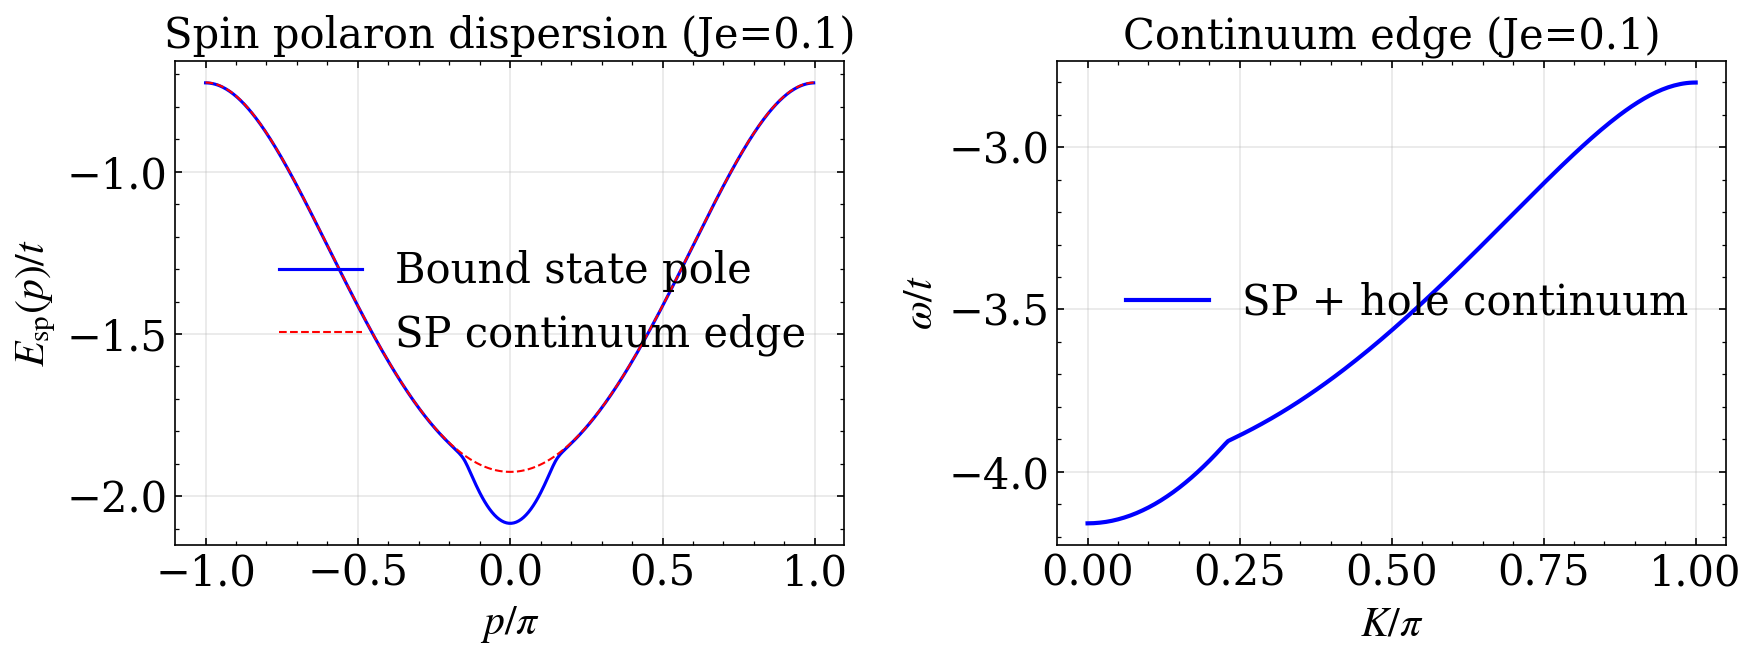

In [62]:
# =====================================================
# Parameters — change Je here
# =====================================================

pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 500, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=omega_values[0])

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=E_sp,
    t_v=t_v,
    Jv=-Jv,
    s=s,
)

# 3) Plot spin-polaron band + continuum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(p_grid/np.pi, E_sp, 'b-', lw=1.5, label='Bound state pole')
ax1.plot(p_grid/np.pi, E_sp_cont, 'r--', lw=1, label='SP continuum edge')
ax1.set_xlabel(r'$p/\pi$')
ax1.set_ylabel(r'$E_{\rm sp}(p)/t$')
ax1.set_title(f'Spin polaron dispersion (Je={Je})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_ex/np.pi, E_cont, 'b-', lw=2, label='SP + hole continuum')
ax2.set_xlabel(r'$K/\pi$')
ax2.set_ylabel(r'$\omega/t$')
ax2.set_title(f'Continuum edge (Je={Je})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sp_continuum_Je_{:.1f}.png'.format(Je), dpi=200, bbox_inches='tight')
print(f"Saved plot.")

# Save data
np.savez('sp_continuum_data_Je_{:.1f}.npz'.format(Je),
         p_grid=p_grid, E_sp=E_sp, E_sp_cont=E_sp_cont,
         K_ex=K_ex, E_cont=E_cont, p_star=p_star, k_h_star=k_h_star)
print("Saved data.")
plt.show()

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_to_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def exciton_bound_energy(k, t_c, t_v, U, Je=0.0, s=0.5):
    """
    Exact exciton bound-state dispersion in the reduced momentum variable k,
    where the formula depends on cos(k).

    k can be scalar or array.
    """
    A = t_c**2 + t_v**2 + 2.0*t_c*t_v*np.cos(k)
    E = -np.sqrt(U**2 + 4.0*A)   # lower / bound branch
    return E



def magnon_dispersion(q, J0, s, Je, Jv):
    """
    Exact 1D FM magnon dispersion in the same energy convention as your solver.
    """
    return 2.0*J0*s*(1.0 - np.cos(q)) + Je*s/2 + Jv*s/2

def exciton_magnon_continuum(K_grid, t_c, t_v, U, J0, s, Je=0.0, Jv=0.0,
                             nq=400):
    """
    Exciton + magnon continuum in the exciton-magnon solver convention.

    K_grid: solver momentum variable K in [0, pi]
    q: physical magnon momentum in [-pi, pi)
    Exciton reduced momentum is k_X = K - q, so cos( k_X) = cos(K - q).

    Returns:
      E_low(K), E_high(K), q_star_low(K), q_star_high(K), E_all(K,q)
    """
    K_grid = np.asarray(K_grid, dtype=float)
    q_grid = np.linspace(-np.pi, np.pi, nq, endpoint=False)

    # Broadcast over K and q
    K2 = K_grid[:, None]
    Q  = q_grid[None, :]

    # Exciton reduced momentum in your exact formula
    kX = K2 - Q

    EX = exciton_bound_energy(
        kX, t_c=t_c, t_v=t_v, U=U, Je=Je, s=s
    )
    WM = magnon_dispersion(Q, J0=J0, s=s, Je=Je, Jv=Jv)

    E_all = EX + WM

    idx_low  = np.argmin(E_all, axis=1)
    idx_high = np.argmax(E_all, axis=1)

    E_low  = E_all[np.arange(len(K_grid)), idx_low]
    E_high = E_all[np.arange(len(K_grid)), idx_high]

    q_star_low  = q_grid[idx_low]
    q_star_high = q_grid[idx_high]

    return E_low, E_high, q_star_low, q_star_high, q_grid, E_all

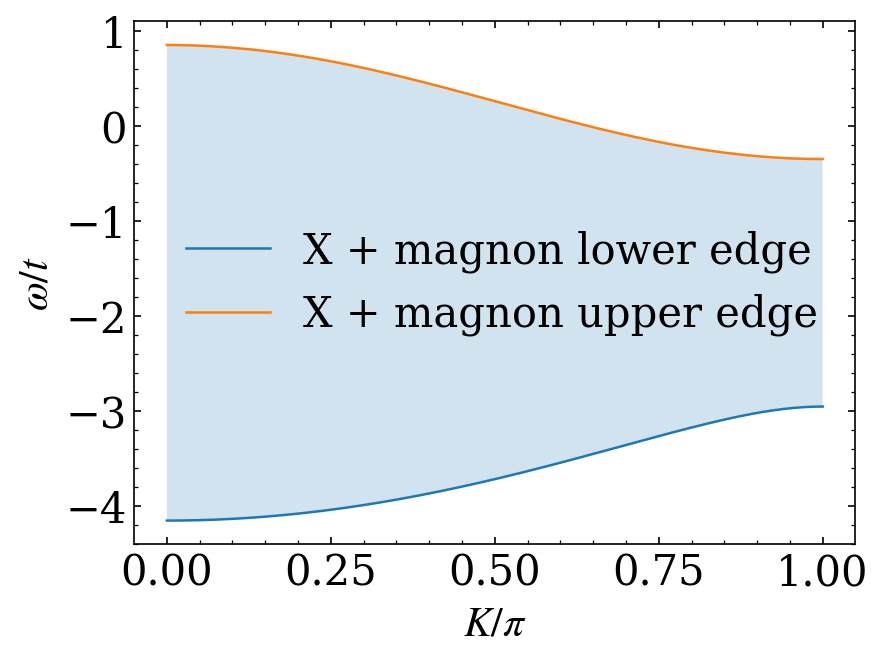

In [64]:
# Parameters


K_grid = k_values

E_low, E_high, q_low, q_high, q_grid, E_all = exciton_magnon_continuum(
    K_grid,
    t_c=t_c,
    t_v=t_v,
    U=-U,
    J0=J0,
    s=s,
    Je=-Je,
    Jv=-Jv,
    nq=400,
)

# Plot edges
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(K_grid/np.pi, E_low,  label='X + magnon lower edge')
ax.plot(K_grid/np.pi, E_high, label='X + magnon upper edge')
ax.fill_between(K_grid/np.pi, E_low, E_high, alpha=0.2)
ax.set_xlabel(r'$K/\pi$')
ax.set_ylabel(r'$\omega/t$')
ax.legend()
plt.tight_layout()
plt.show()

In [65]:
pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=-Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t_c)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=E_sp,
    t_v=t_v,
    Jv=-Jv,
    s=s,
)

Extracting spin polaron band for Je=0.1...
  Found poles at 1/400 k-points
  Missing poles near k/pi = [-1.    -0.995 -0.99  -0.985 -0.98 ] ...
  Min binding energy: 0.000001
  Max binding energy: 0.000001


In [66]:
class RealSpaceHolePolaron:
    def __init__(self, t, J_0, J_v, s, gamma=1.0):
        self.t = float(t)
        self.J_0 = float(J_0)
        self.J_v = float(J_v)
        self.s = float(s)
        self.gamma = float(gamma)

    def denominator(self, z, K):
        z = np.asarray(z, dtype=np.complex128)
        K = np.asarray(K, dtype=float)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_v * self.s
        disc = alpha**2 - 4.0 * A_plus * A_minus
        sqrt_disc = np.sqrt(disc + 0j)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = z - 2.0 * self.J_0 * self.s - 0.5 * self.J_v * (self.s - 1.0)
        g2 = (self.gamma * self.J_v)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        return z + 2.0 * self.t * np.cos(K) + 0.5 * self.J_v * self.s - Sigma

    def denominator_real_below_continuum(self, omega, K):
        """
        D(omega, K) on the real axis, below the SP continuum (disc >= 0, D real).
        Accepts scalar or array omega; K scalar. Returns float or ndarray.
        """
        omega = np.asarray(omega, dtype=float)
        K = float(K)
        A_plus  = self.t * np.exp(1j * K) + self.s * self.J_0
        A_minus = self.t * np.exp(-1j * K) + self.s * self.J_0
        alpha = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_v * self.s
        disc = alpha**2 - 4.0 * (A_plus * A_minus).real
        disc = np.clip(disc, 0.0, None)              # clamp at edge, elementwise
        sqrt_disc = np.sqrt(disc)
        rho1 = (-alpha + sqrt_disc) / (2.0 * A_minus)
        rho2 = (-alpha - sqrt_disc) / (2.0 * A_minus)
        rho = np.where(np.abs(rho1) < np.abs(rho2), rho1, rho2)
        beta = omega - 2.0 * self.J_0 * self.s - 0.5 * self.J_v * (self.s - 1.0)
        g2 = (self.gamma * self.J_v)**2 * self.s / 2.0
        Sigma = g2 / (beta + 2.0 * A_minus * rho)
        result = omega + 2.0 * self.t * np.cos(K) + 0.5 * self.J_v * self.s - Sigma
        return result.real if result.ndim else float(result.real)

    def sp_continuum_edge(self, K):
        """Lower edge of the spin-polaron continuum at momentum K."""
        K = float(K)
        q = np.linspace(-np.pi, np.pi, 5000)
        E = (-2.0 * self.t * np.cos(K - q)
             + 2.0 * self.J_0 * self.s * (1.0 - np.cos(q))
             + 0.5 * self.J_v * self.s)
        return float(np.min(E))

    def G_minus(self, z, K):
        return 1.0 / self.denominator(z, K)

    def spectral_weight(self, K, omega, eta=2e-2):
        z = omega + 1j * eta
        return -np.imag(self.G_minus(z, K)) / np.pi

In [67]:
hol = RealSpaceHolePolaron(t=t_v, J_0=J0, J_v=-Jv, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
H_sp, E_sp_cont = extract_lowest_spin_polaron_band(hol, p_grid, wmin=-8.0*t_v)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
H_cont, Hp_star, Hk_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=H_sp,
    t_v=t_c,
    Jv=-Je,
    s=s,
)

Extracting spin polaron band for Je=0.1...
  Found poles at 1/400 k-points
  Missing poles near k/pi = [-1.    -0.995 -0.99  -0.985 -0.98 ] ...
  Min binding energy: 0.000001
  Max binding energy: 0.000001


Plot saved to outputs/spectral_function_2d.png


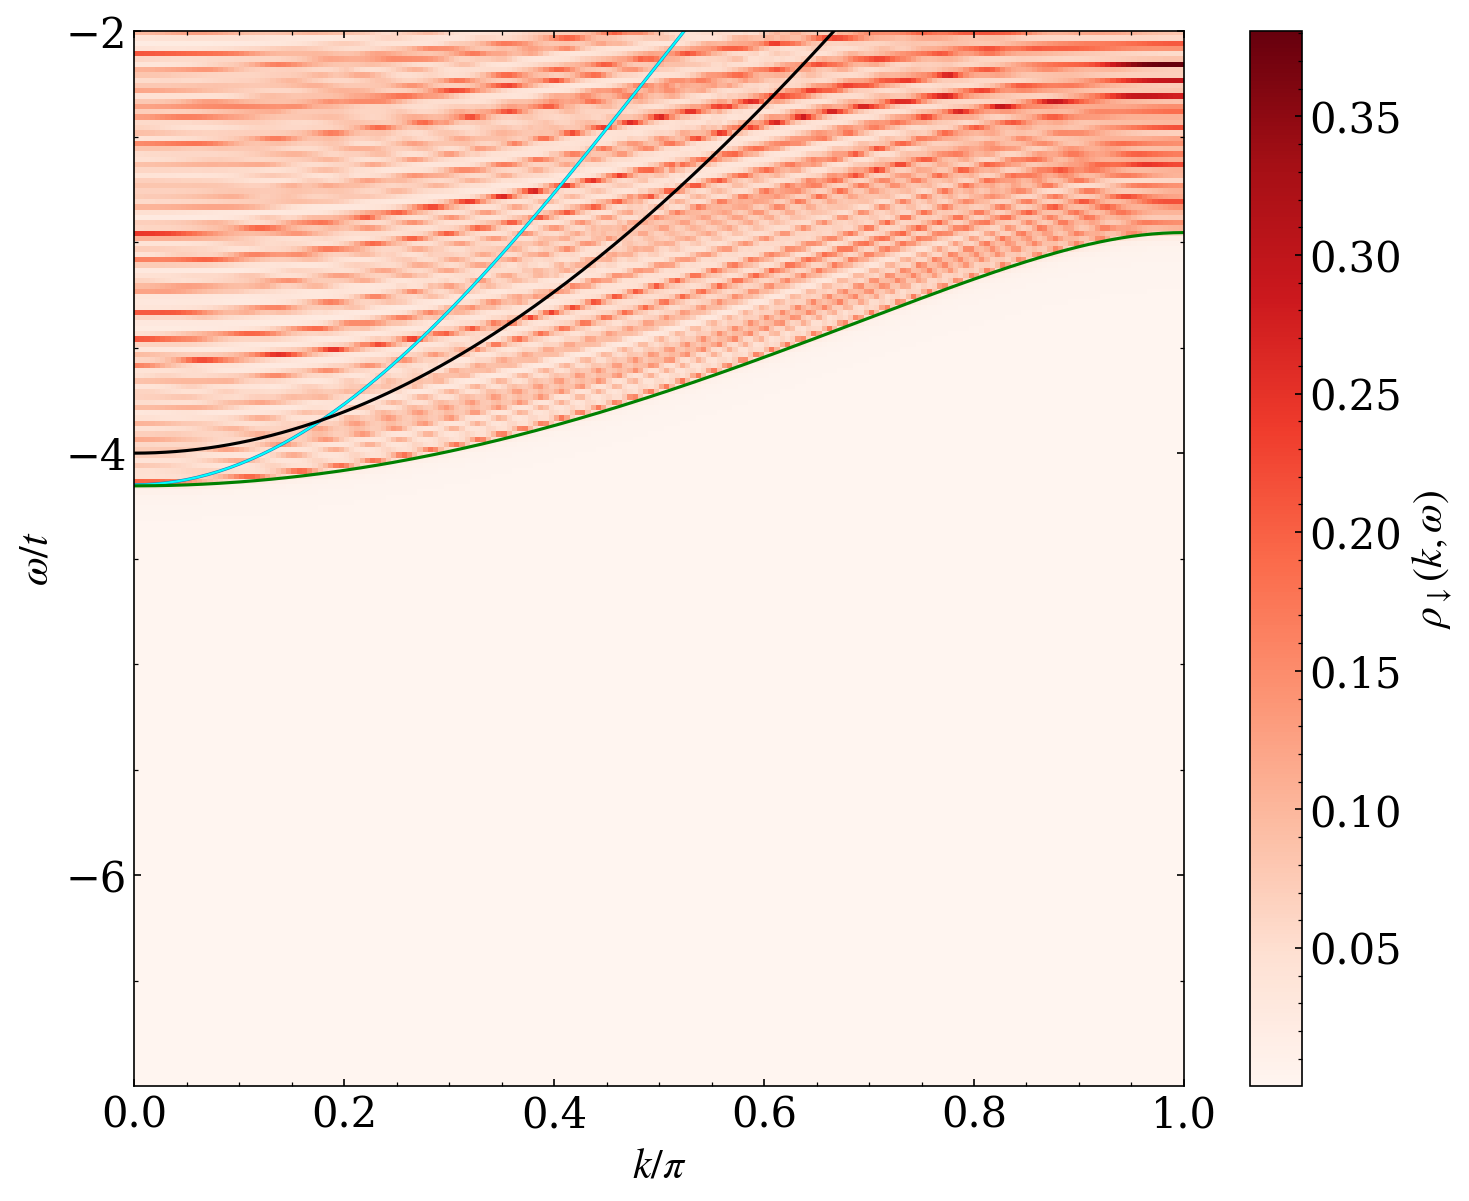

In [68]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot as 2D image
im = ax.imshow(spectral_2d,
               extent=[0, 1, omega_values[0], omega_values[-1]],
               aspect='auto',
               origin='lower',
               cmap='Reds',  # inverted grayscale like the figure
                )

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\rho_\downarrow(k,\omega)$')

#plt.plot(k_values/np.pi,-5.2-0.7*np.cos(2*k_values) )

ax.plot(k_values/np.pi, E_cont, label="spin-polaron+hole", lw=1.5)
ax.plot(k_values/np.pi, H_cont, label="hole-spin-polaron+hole", color = "cyan", lw=1)
ax.plot(K_grid/np.pi, E_low , color='g', lw=1.5)
#plt.plot(k_values/np.pi, min_values_abs)
# Add dashed line at omega=0 (or wherever appropriate)
#ax.axhline(-0.75, ls='--', c='grey', lw=2, alpha=0.5)
#plt.plot(k_values/np.pi, q_min_array + E_min_array)
#plt.plot(k_values/np.pi, -4*np.abs(t_c*np.cos(k_values)))
plt.plot(k_values/np.pi, -2*(t_c+t_v)*np.abs(np.cos(k_values/2)), color = "k", lw=1.5)
#plt.ylim(-4.4,-4.2)
# Labels
ax.set_xlabel(r'$k/\pi$')
ax.set_ylabel(r'$\omega/t$')
#ax.text(0.95, 0.05, '(b)', transform=ax.transAxes,
#        fontsize=12, verticalalignment='bottom', horizontalalignment='right')
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.savefig('spectral_function_2d.png', dpi=200, bbox_inches='tight')
print("Plot saved to outputs/spectral_function_2d.png")
#ax.axhline(11,color='r', linestyle='--')
#ax.axhline(3,color='r', linestyle='--')
ax.set_ylim(-7, -2)
#ax.axhline(-15.5,color='g', linestyle='--')
#ax.axhline(-12.5,color='g', linestyle='--')
plt.show()

In [69]:
s = 1.5
Je = 0.1# 0.1
Jv = 0.1# 0.1
t_c = 1.0
J0 = 0.2
gamma = 1.0
t_v = 1.0
U = 0.2 # 0.1 dissociate, above 0.4 there are no more dissociation

# as long as J's are positive and U is small, then we have dissociation
# When J's are negative, then Tp will always have an exciton below the continuum

params = dict(
    t_c=t_c,
    t_v=t_v,
    Delta=0,
    J_FM=J0,
    Je=Je,
    Jv=Jv,
    s=s,
    gamma=gamma,
    U=U,
    Rmax=50,
    M=10,
)


k_values = np.linspace(0, np.pi, 200)
omega_values = np.linspace(-5*t_c, -4*t_c, 200)
eta = 0.001

solver = ExcitonMagnonSolver(**params)

In [70]:
col = np.empty(len(omega_values), dtype=float)
for j, w in enumerate(omega_values):
    col[j] = solver.spectral(
        0, w,
        eta=eta,
        R=0,
        sector="Tp",
        source="Tp",
        m = 0,#None
        Rsrc=0,
        msrc=0, #None
    )
    


In [71]:
pol = RealSpaceMagneticPolaron(t=t_c, J_0=J0, J_e=-Je, s=s, gamma=gamma)

# 1) Exact spin-polaron dispersion
p_grid = np.linspace(-np.pi, np.pi, 400, endpoint=False)
print(f"Extracting spin polaron band for Je={Je}...")
E_sp, E_sp_cont = extract_lowest_spin_polaron_band(pol, p_grid, wmin=-8.0*t_c)

n_valid = np.sum(~np.isnan(E_sp))
n_total = len(E_sp)
print(f"  Found poles at {n_valid}/{n_total} k-points")
if n_valid < n_total:
    n_missing = n_total - n_valid
    missing_k = p_grid[np.isnan(E_sp)]
    print(f"  Missing poles near k/pi = {missing_k[:5]/np.pi} ...")

# Check binding energy
binding = E_sp_cont - E_sp
print(f"  Min binding energy: {np.nanmin(binding):.6f}")
print(f"  Max binding energy: {np.nanmax(binding):.6f}")

# 2) Build the sp + hole continuum
K_ex = k_values
E_cont, p_star, k_h_star = spin_polaron_hole_continuum(
    K_ex_grid=K_ex,
    p_grid=p_grid,
    E_sp=E_sp,
    t_v=t_v,
    Jv=-Jv,
    s=s,
)

Extracting spin polaron band for Je=0.1...
  Found poles at 1/400 k-points
  Missing poles near k/pi = [-1.    -0.995 -0.99  -0.985 -0.98 ] ...
  Min binding energy: 0.000001
  Max binding energy: 0.000001


(0.0, 3.0)

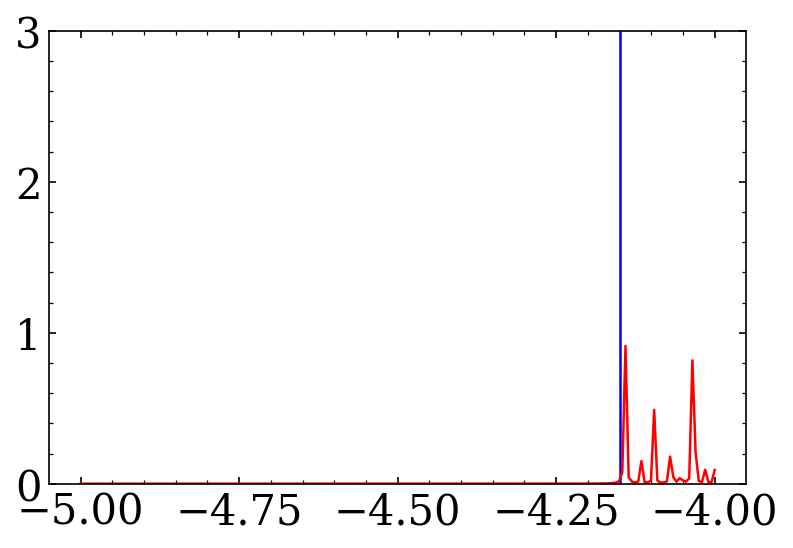

In [72]:
plt.plot(omega_values, col, color = "r")
plt.vlines(E_cont[0],0,3, color = "b")
plt.ylim(0,3)